## 2. ANALAZING THE DEMOGRAPHIC AND CLINICAL INFO


EDA of matched fundus images with diopters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MATCHTABLE_PATH = Path(r"C:\Users\paula\0B_TFGBiomed\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos.xlsx")

MYOPIA_THRESHOLD = -0.50
HIGH_MYOPIA_THRESHOLD = -6.00

print("Input Excel matched with eye pics:", MATCHTABLE_PATH)

Input Excel matched with eye pics: C:\Users\paula\0B_TFGBiomed\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos.xlsx


### 1) Load Excel

In [2]:
df_matches = pd.read_excel(MATCHTABLE_PATH)

print("Shape of table matching patients' SEs with pics:", df_matches.shape)
df_matches.head()

Shape of table matching patients' SEs with pics: (2346, 29)


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,OI_ESF,OI_CIL,OI_EJE,EquivalenteEsférico_Derecho,EquivalenteEsférico_Izquierdo,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label
0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6.0,...,0.00,0.00,0.0,0.00,0.000,SI,2024-09-17,id+date,0.000,0.0
1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6.0,...,0.00,0.00,0.0,0.00,0.000,SI,2024-09-17,id+date,0.000,0.0
2,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51.0,...,-0.25,-0.75,180.0,-2.25,-0.625,NO,2023-12-11,id+date,-2.250,1.0
3,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51.0,...,-0.25,-0.75,180.0,-2.25,-0.625,NO,2023-12-11,id+date,-0.625,1.0
4,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26.0,...,-0.25,0.00,0.0,0.00,-0.250,NO,2023-04-12,id+date,0.000,0.0


In [3]:
print("Number of patients with SE and pictures matched: ", len(df_matches) - df_matches["nhc"].isna().sum() )

Number of patients with SE and pictures matched:  2126


### 2) Filter Excel lines to only lines that matched images with SE

In [4]:
df = df_matches.copy()

#Cleaning up first
df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")
df["Edad"] = pd.to_numeric(df["Edad"], errors="coerce")
df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce")

df = df[
    df["filename"].notna()
    & df["image_path"].notna()
    & df["target_SE"].notna()
].copy()

print("Rows in original Excel:", len(df_matches))
print("Rows excluded:", len(df_matches) - len(df))
print("Rows kept for analysis:", len(df))
print("Unique patients:", df["patient_id"].nunique())

Rows in original Excel: 2346
Rows excluded: 220
Rows kept for analysis: 2126
Unique patients: 1061


### 3) Clean categories: 

con lo que se me ocurra que puede haber distinto, aunque el Excel es bastante limpio ya

In [5]:
#what we already had:
df["sex_M/F"] = (
    df["Sexo"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "femenino": "Female",
        "masculino": "Male",
        "mujer": "Female",
        "hombre": "Male",
        "female": "Female",
        "male": "Male",
        "nan": np.nan,
        "none": np.nan
    })
)

df["eye_L/R"] = (
    df["eye"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "R": "Right eye",
        "OD": "Right eye",
        "D": "Right eye",
        "L": "Left eye",
        "OI": "Left eye",
        "I": "Left eye",
        "NAN": np.nan,
        "NONE": np.nan
    })
)

df["modality_color/IR"] = (
    df["modality"]
    .astype(str)
    .str.strip()
    .replace({
        "nan": np.nan,
        "None": np.nan
    })
)

# Adding extra markers for further EDA:
df["age10_group"] = np.where(df["Edad"] < 10, "Under 10", "10 or over")
df["age18_group"] = np.where(df["Edad"] < 18, "Under 18", "18 or over")
df["age_group_detailed"] = pd.cut(
    df["Edad"],
    bins=[0, 10, 18, 30, 45, 60, 75, 120],
    labels=["<10", "10-17", "18-29", "30-44", "45-59", "60-74", ">=75"],
    right=False
)

df["myopia/normal"] = np.where(
    df["target_SE"] <= MYOPIA_THRESHOLD,
    "Myopia",
    "Normal"
)
df["is_myopic"] = (df["target_SE"] <= MYOPIA_THRESHOLD).astype(int) #1 Y, 0 N

conditions = [
    df["target_SE"] > MYOPIA_THRESHOLD,
    (df["target_SE"] <= MYOPIA_THRESHOLD) & (df["target_SE"] >= HIGH_MYOPIA_THRESHOLD),
    df["target_SE"] < HIGH_MYOPIA_THRESHOLD
]
choices = [
    "Normal",
    "Low myopia",
    "High myopia"
]
df["refractive_group"] = np.select(conditions, choices, default="Unknown")

display(df[[
    "filename", "patient_id", "Edad", "sex_M/F", "eye_L/R",
    "modality_color/IR", "target_SE", "myopia/normal", "refractive_group"
]].head())

#This analyses will help us further divide our data into subsections for models training on selected groups of patients

,filename,patient_id,Edad,sex_M/F,eye_L/R,modality_color/IR,target_SE,myopia/normal,refractive_group
0,A6138_17092024_165654_Color_R_001.jpg,A6138,6.0,Male,Right eye,Color,0.000,Normal,Normal
1,A6138_17092024_165721_Color_L_001.jpg,A6138,6.0,Male,Left eye,Color,0.000,Normal,Normal
2,A6140_11122023_191157_IR_R_001.jpg,A6140,51.0,Female,Right eye,IR,-2.250,Myopia,Low myopia
3,A6140_11122023_191221_IR_L_001.jpg,A6140,51.0,Female,Left eye,IR,-0.625,Myopia,Low myopia
4,A6142_12042023_153339_Color_R_001.jpg,A6142,26.0,Female,Right eye,Color,0.000,Normal,Normal


### 4) Helper functions

In [33]:
def count_table(data, col, patient_col="patient_id"):
    table = (
        data.groupby(col, dropna=False)
        .agg(
            n_images=("filename", "count"),
            n_patients=(patient_col, "nunique")
        )
        .reset_index()
    )
    table["image_%"] = 100 * table["n_images"] / table["n_images"].sum()
    table["patient_%"] = 100 * table["n_patients"] / table["n_patients"].sum()
    return table.sort_values("n_images", ascending=False)

def crosstab_counts(data, row, col):
    return pd.crosstab(data[row], data[col], margins=True) #tabulación cruzada

def crosstab_percent(data, row, col):
    return (pd.crosstab(data[row], data[col], normalize="index") * 100).round(2)

def plot_count_table(df, x_col, y_col="n_images", title="", rotation=0, figsize=(8,5)):
    plt.figure(figsize=figsize)

    bars = plt.bar(df[x_col].astype(str), df[y_col])

    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel("Number of images")
    plt.xticks(rotation=rotation)

    # etiquetas encima de las barras
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    plt.show()

def plot_histogram(df, column, bins=50, title=None):
    plt.figure(figsize=(8,4))
    plt.hist(df[column], bins=bins)
    plt.xlabel(column)
    plt.ylabel("Count")

    if title:
        plt.title(title)
        
    plt.tight_layout()
    plt.show()


def plot_grouped_boxplot( df, x_col, y_col, title=None, rotation=0, figsize=(8,4), save_path=None):
    plt.figure(figsize=figsize)

    groups = [
        df[df[x_col] == value][y_col].dropna()
        for value in df[x_col].dropna().unique()
    ]

    plt.boxplot(
        groups,
        tick_labels=df[x_col].dropna().unique()
    )

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    if title:
        plt.title(title)

    plt.xticks(rotation=rotation)

    plt.tight_layout()

    plt.show()

### 5) General summary printed pretty

In [7]:
general_summary = pd.DataFrame({
    "Metric": [
        "Total matched images with diopters",
        "Unique patients",
        "Mean images per patient",
        "Mean age",
        "Median age",
        "Minimum age",
        "Maximum age",
        "Mean spherical equivalent",
        "Median spherical equivalent",
        "Minimum spherical equivalent",
        "Maximum spherical equivalent",
        "Myopia threshold",
        "High myopia threshold"
    ],
    "Value": [
        len(df),
        df["patient_id"].nunique(),
        df.groupby("patient_id")["filename"].count().mean(),
        df["Edad"].mean(),
        df["Edad"].median(),
        df["Edad"].min(),
        df["Edad"].max(),
        df["target_SE"].mean(),
        df["target_SE"].median(),
        df["target_SE"].min(),
        df["target_SE"].max(),
        MYOPIA_THRESHOLD,
        HIGH_MYOPIA_THRESHOLD
    ]
})

#Let us have decimals only when NOT an integer
general_summary["Value"] = general_summary["Value"].map(
    lambda x: f"{x:.0f}" if float(x).is_integer() else f"{x:.2f}"
)
display(general_summary)

,Metric,Value
0,Total matched images with diopters,2126
1,Unique patients,1061
2,Mean images per patient,2.00
3,Mean age,35.41
4,Median age,42
5,Minimum age,2
6,Maximum age,99
7,Mean spherical equivalent,0.02
8,Median spherical equivalent,0
9,Minimum spherical equivalent,-20.38


### 6) Main distributions: vamos a ver cómo se componen los subgrupos que queremos estudiar

In [8]:
tables = {
    "myopia_vs_normal": count_table(df, "myopia/normal"),
    "high_low_myopia": count_table(df, "refractive_group"),
    "under_over_18": count_table(df, "age18_group"),
    "under_over_10": count_table(df, "age10_group"),
    "female_vs_male": count_table(df, "sex_M/F"),
    "right_vs_left_eye": count_table(df, "eye_L/R"),
    "modality": count_table(df, "modality_color/IR"),
    "age_detailed": count_table(df, "age_group_detailed"),
}

for name, table in tables.items():
    print("\n", "="*80)
    print(name)
    display(table)


myopia_vs_normal


C:\Users\paula\AppData\Local\Temp\ipykernel_4688\2354670097.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(col, dropna=False)


,myopia/normal,n_images,n_patients,image_%,patient_%
1,Normal,1645,861,77.375353,75.925926
0,Myopia,481,273,22.624647,24.074074



high_low_myopia


,refractive_group,n_images,n_patients,image_%,patient_%
2,Normal,1645,861,77.375353,75.394046
1,Low myopia,449,262,21.119473,22.942207
0,High myopia,32,19,1.505174,1.663748


...

,eye_L/R,n_images,n_patients,image_%,patient_%
0,Left eye,1070,1049,50.329257,50.287632
1,Right eye,1056,1037,49.670743,49.712368



modality


,modality_color/IR,n_images,n_patients,image_%,patient_%
0,Color,1960,996,92.19191,90.627843
1,IR,166,103,7.80809,9.372157



age_detailed


,age_group_detailed,n_images,n_patients,image_%,patient_%
4,45-59,620,308,29.162747,29.029218
0,<10,509,254,23.941675,23.939680
1,10-17,308,153,14.487300,14.420358
3,30-44,229,115,10.771402,10.838831
5,60-74,214,106,10.065851,9.990575
6,>=75,137,70,6.444026,6.597549
2,18-29,109,55,5.126999,5.183789


### 7) Myopia vs normal by subgroup

In [9]:
subgroups = {
    "sex_vs_myopia": "sex_M/F",
    "eye_vs_myopia": "eye_L/R",
    "modality_vs_myopia": "modality_color/IR",
    "age10_vs_myopia": "age10_group",
    "age18_vs_myopia": "age18_group",
    "age_detailed_vs_myopia": "age_group_detailed",
}

for name, row_col in subgroups.items():
    print("\n", "="*80)
    print(name, "- counts")
    counts = crosstab_counts(df, row_col, "myopia/normal")
    display(counts)

    print(name, "- row percentages")
    pct = crosstab_percent(df, row_col, "myopia/normal")
    display(pct)


sex_vs_myopia - counts


myopia/normal,Myopia,Normal,All
sex_M/F,,,
Female,310,1005,1315
Male,171,640,811
All,481,1645,2126


sex_vs_myopia - row percentages


myopia/normal,Myopia,Normal
sex_M/F,,
Female,23.57,76.43
Male,21.09,78.91



eye_vs_myopia - counts


...

myopia/normal,Myopia,Normal
age18_group,,
18 or over,31.40,68.60
Under 18,8.57,91.43



age_detailed_vs_myopia - counts


myopia/normal,Myopia,Normal,All
age_group_detailed,,,
<10,22,487,509
10-17,48,260,308
18-29,38,71,109
30-44,99,130,229
45-59,195,425,620
60-74,49,165,214
>=75,30,107,137
All,481,1645,2126


age_detailed_vs_myopia - row percentages


myopia/normal,Myopia,Normal
age_group_detailed,,
<10,4.32,95.68
10-17,15.58,84.42
18-29,34.86,65.14
30-44,43.23,56.77
45-59,31.45,68.55
60-74,22.90,77.10
>=75,21.90,78.10


### 8) High vs low myopia by subgroup

In [10]:
subgroups = {
    "sex_vs_refractive_group": "sex_M/F",
    "eye_vs_refractive_group": "eye_L/R",
    "modality_vs_refractive_group": "modality_color/IR",
    "age10_vs_refractive_group": "age10_group",
    "age18_vs_refractive_group": "age18_group",
    "age_detailed_vs_refractive_group": "age_group_detailed",
}

for name, row_col in subgroups.items():
    print("\n", "="*80)
    print(name, "- counts")
    counts = crosstab_counts(df, row_col, "refractive_group")
    display(counts)

    print(name, "- row percentages")
    pct = crosstab_percent(df, row_col, "refractive_group")
    display(pct)



sex_vs_refractive_group - counts


refractive_group,High myopia,Low myopia,Normal,All
sex_M/F,,,,
Female,19,291,1005,1315
Male,13,158,640,811
All,32,449,1645,2126


sex_vs_refractive_group - row percentages


refractive_group,High myopia,Low myopia,Normal
sex_M/F,,,
Female,1.44,22.13,76.43
Male,1.60,19.48,78.91



eye_vs_refractive_group - counts


...

refractive_group,High myopia,Low myopia,Normal
age18_group,,,
18 or over,2.14,29.26,68.60
Under 18,0.49,8.08,91.43



age_detailed_vs_refractive_group - counts


refractive_group,High myopia,Low myopia,Normal,All
age_group_detailed,,,,
<10,0,22,487,509
10-17,4,44,260,308
18-29,1,37,71,109
30-44,2,97,130,229
45-59,19,176,425,620
60-74,6,43,165,214
>=75,0,30,107,137
All,32,449,1645,2126


age_detailed_vs_refractive_group - row percentages


refractive_group,High myopia,Low myopia,Normal
age_group_detailed,,,
<10,0.00,4.32,95.68
10-17,1.30,14.29,84.42
18-29,0.92,33.94,65.14
30-44,0.87,42.36,56.77
45-59,3.06,28.39,68.55
60-74,2.80,20.09,77.10
>=75,0.00,21.90,78.10


### 9) IR characterization: let's dig deeper into IR pics to see what their patients look like

In [11]:
df_ir = df[df["modality_color/IR"].str.upper() == "IR"].copy()
df_color = df[df["modality_color/IR"].str.upper() == "COLOR"].copy()

ir_summary = pd.DataFrame({
    "Metric": [
        "IR images",
        "IR patients",
        "Mean IR age",
        "Median IR age",
        "Minimum IR age",
        "Maximum IR age",
        "Mean IR spherical equivalent",
        "Median IR spherical equivalent",
        "IR myopic images",
        "IR normal images",
        "IR high myopia images",
        "IR low myopia images"
    ],
    "Value": [
        len(df_ir),
        df_ir["patient_id"].nunique(),
        df_ir["Edad"].mean(),
        df_ir["Edad"].median(),
        df_ir["Edad"].min(),
        df_ir["Edad"].max(),
        df_ir["target_SE"].mean(),
        df_ir["target_SE"].median(),
        (df_ir["myopia/normal"] == "Myopia").sum(),
        (df_ir["myopia/normal"] == "Normal").sum(),
        (df_ir["refractive_group"] == "High myopia").sum(),
        (df_ir["refractive_group"] == "Low myopia").sum(),
    ]
})

#Let us have decimals only when NOT an integer
ir_summary["Value"] = ir_summary["Value"].map(
    lambda x: f"{x:.0f}" if float(x).is_integer() else f"{x:.2f}"
)
display(ir_summary)

print("IR: age groups")
display(count_table(df_ir, "age_group_detailed"))

print("Seems as if most patients with IR pics are youngest of the group (54% under 10 and 20% between 10 and 17")

,Metric,Value
0,IR images,166
1,IR patients,103
2,Mean IR age,16.20
3,Median IR age,8
4,Minimum IR age,4
5,Maximum IR age,86
6,Mean IR spherical equivalent,0.20
7,Median IR spherical equivalent,0
8,IR myopic images,36
9,IR normal images,130


IR: age groups


C:\Users\paula\AppData\Local\Temp\ipykernel_4688\2354670097.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(col, dropna=False)


,age_group_detailed,n_images,n_patients,image_%,patient_%
0,<10,96,56,57.831325,54.368932
1,10-17,32,21,19.277108,20.388350
2,18-29,13,7,7.831325,6.796117
4,45-59,12,9,7.228916,8.737864
3,30-44,5,4,3.012048,3.883495
5,60-74,5,4,3.012048,3.883495
6,>=75,3,2,1.807229,1.941748


Seems as if most patients with IR pics are youngest of the group (54% under 10 and 20% between 10 and 17


### 11) Target_SE summaries

In [12]:
target_summary_global = df["target_SE"].describe().to_frame(name="target_SE")

target_by_sex = df.groupby("sex_M/F")["target_SE"].describe()
target_by_eye = df.groupby("eye_L/R")["target_SE"].describe()
target_by_modality = df.groupby("modality_color/IR")["target_SE"].describe()
target_by_age10 = df.groupby("age10_group")["target_SE"].describe()
target_by_age18 = df.groupby("age18_group")["target_SE"].describe()
target_by_age_detailed = df.groupby("age_group_detailed")["target_SE"].describe()
target_by_myopia = df.groupby("myopia/normal")["target_SE"].describe()
target_by_refractive = df.groupby("refractive_group")["target_SE"].describe()

#Let us have decimals only when NOT an integer
target_summary_global = target_summary_global.map(
    lambda x: f"{x:.0f}" if float(x).is_integer() else f"{x:.2f}"
)
display(target_summary_global)
display(target_by_sex)
display(target_by_eye)
display(target_by_modality)
display(target_by_age10)
display(target_by_age18)
display(target_by_age_detailed)
display(target_by_myopia)
display(target_by_refractive)

C:\Users\paula\AppData\Local\Temp\ipykernel_4688\1401131112.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  target_by_age_detailed = df.groupby("age_group_detailed")["target_SE"].describe()


,target_SE
count,2126
mean,0.02
std,2.11
min,-20.38
25%,-0.25
50%,0
75%,0.75
max,9


,count,mean,std,min,25%,50%,75%,max
sex_M/F,,,,,,,,
Female,1315.0,0.025570,2.193123,-20.375,-0.375,0.0,0.75,9.00
Male,811.0,0.015413,1.966441,-14.000,-0.250,0.0,0.50,7.75


,count,mean,std,min,25%,50%,75%,max
eye_L/R,,,,,,,,
Left eye,1070.0,0.045678,2.102892,-20.000,-0.25,0.0,0.750,9.000
Right eye,1056.0,-0.002604,2.116013,-20.375,-0.25,0.0,0.625,8.625


,count,mean,std,min,25%,50%,75%,max
modality_color/IR,,,,,,,,
Color,1960.0,0.006186,2.136042,-20.375,-0.25,0.0,0.625,9.00
IR,166.0,0.204819,1.754602,-6.125,-0.25,0.0,0.750,5.25


,count,mean,std,min,25%,50%,75%,max
age10_group,,,,,,,,
10 or over,1617.0,-0.194264,2.207164,-20.375,-0.625,0.0,0.5,9.00
Under 10,509.0,0.707760,1.577925,-3.625,0.000,0.0,1.0,7.75


,count,mean,std,min,25%,50%,75%,max
age18_group,,,,,,,,
18 or over,1309.0,-0.305863,2.273481,-20.375,-0.75,0.0,0.500,9.00
Under 18,817.0,0.546512,1.688390,-8.875,0.00,0.0,0.875,7.75


,count,mean,std,min,25%,50%,75%,max
age_group_detailed,,,,,,,,
<10,509.0,0.707760,1.577925,-3.625,0.00000,0.000,1.000,7.75
10-17,308.0,0.280032,1.828289,-8.875,-0.03125,0.000,0.625,7.75
18-29,109.0,-0.030963,2.110322,-6.375,-1.00000,-0.125,0.250,7.25
30-44,229.0,-0.696507,1.767923,-6.750,-1.25000,-0.250,0.000,5.00
45-59,620.0,-0.467742,2.534867,-20.375,-0.75000,0.000,0.500,9.00
60-74,214.0,0.023949,2.295432,-12.375,-0.34375,0.250,1.000,6.25
>=75,137.0,0.345803,1.549376,-4.875,-0.37500,0.000,1.000,5.25


,count,mean,std,min,25%,50%,75%,max
myopia/normal,,,,,,,,
Myopia,481.0,-2.423857,2.432370,-20.375,-3.0,-1.625,-0.875,-0.5
Normal,1645.0,0.736778,1.326899,-0.375,0.0,0.125,1.000,9.0


,count,mean,std,min,25%,50%,75%,max
refractive_group,,,,,,,,
High myopia,32.0,-9.273438,3.530318,-20.375,-10.75,-8.375,-6.71875,-6.125
Low myopia,449.0,-1.935690,1.373530,-6.000,-2.50,-1.500,-0.87500,-0.500
Normal,1645.0,0.736778,1.326899,-0.375,0.00,0.125,1.00000,9.000


In [13]:
df["target_SE"].value_counts().sort_index()

target_SE
-20.375    1
-20.000    1
-14.000    1
-12.375    1
-11.750    1
          ..
 7.250     2
 7.625     2
 7.750     2
 8.625     1
 9.000     1
Name: count, Length: 126, dtype: int64

In [14]:
print("⚠️ 126 valores distintos de target_SE para 2126 imágenes estudiables")

⚠️ 126 valores distintos de target_SE para 2126 imágenes estudiables


### 12) Plots: main bar charts

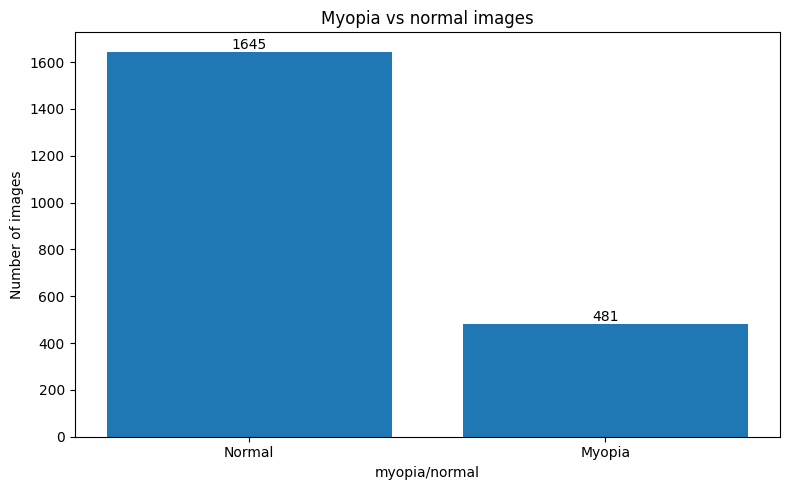

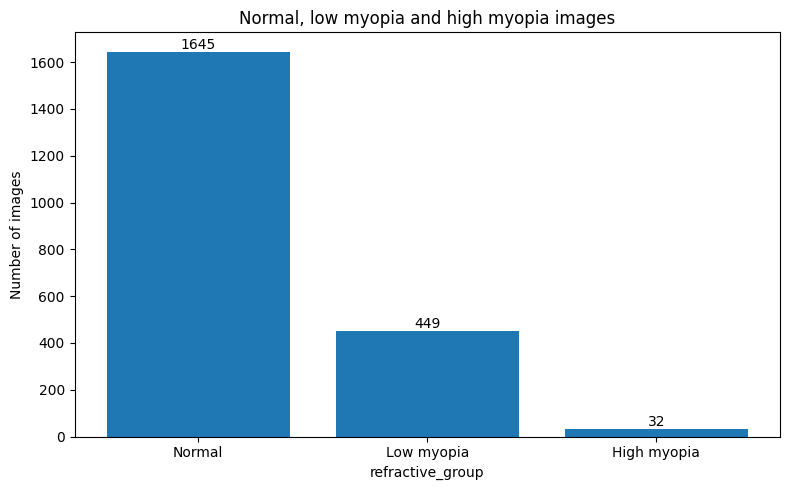

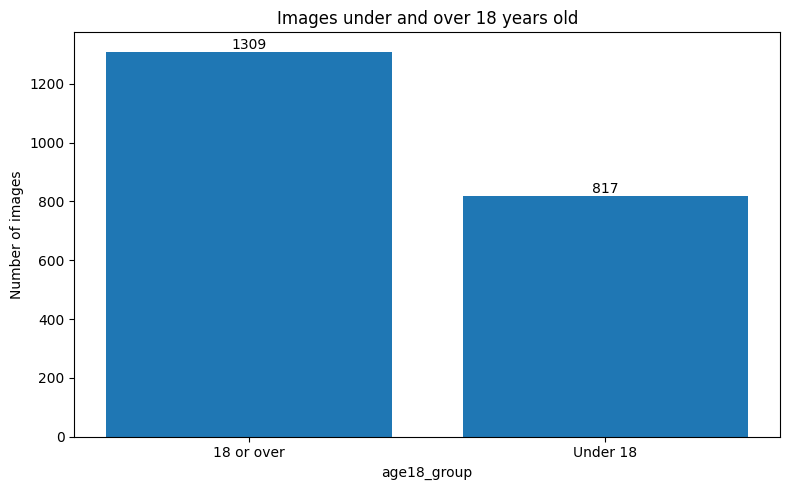

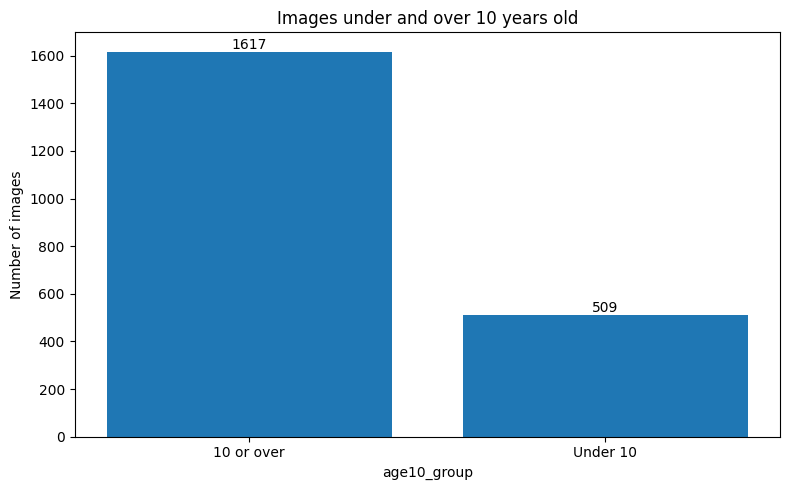

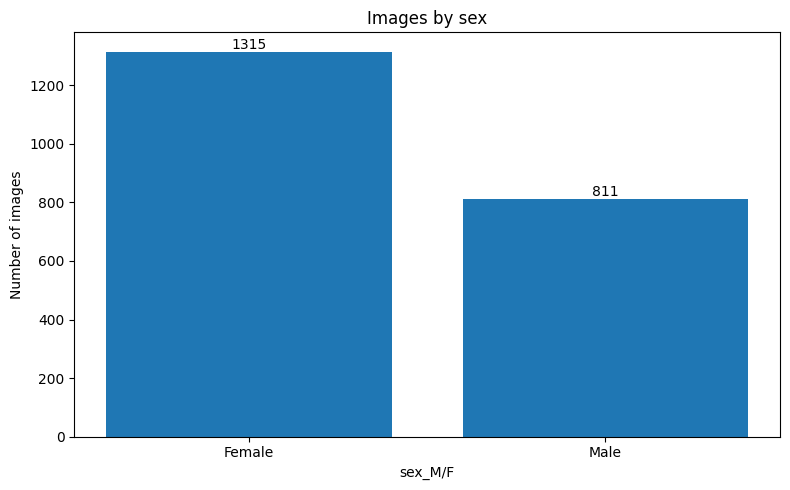

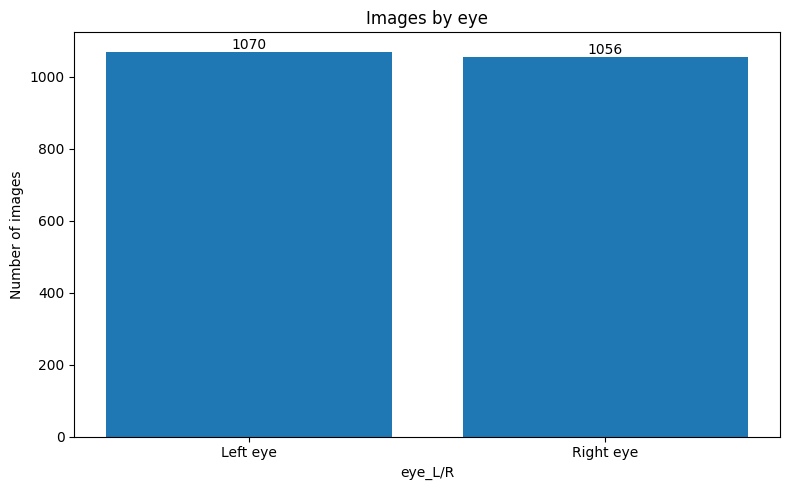

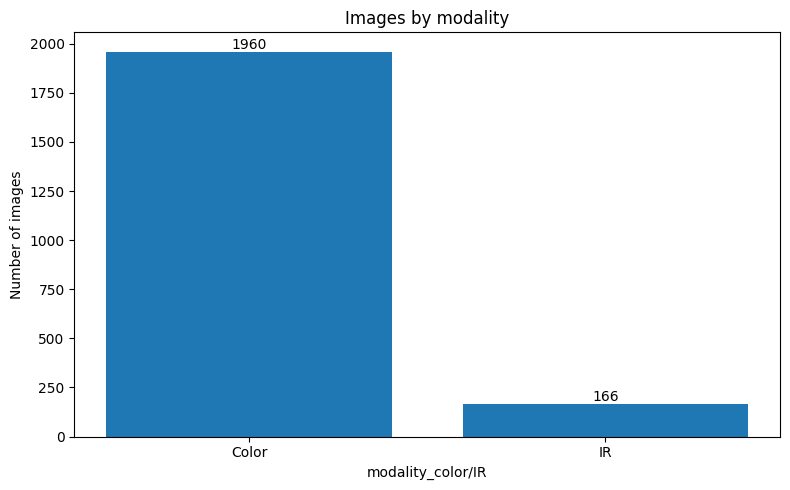

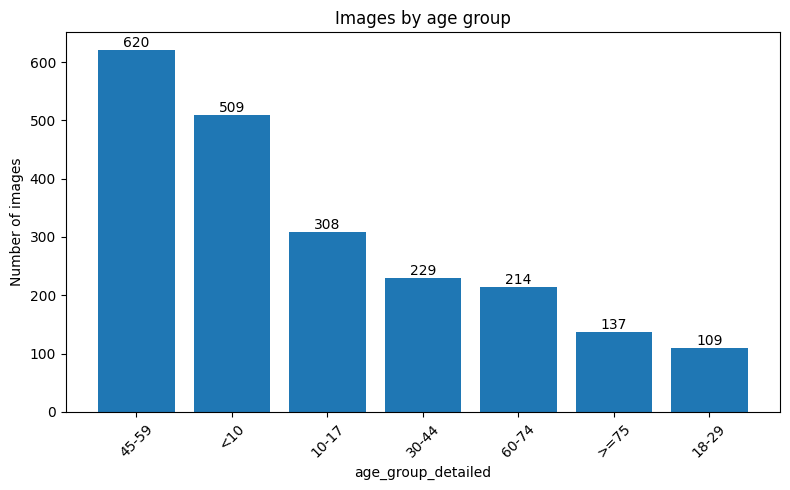

In [15]:
plot_count_table(
    tables["myopia_vs_normal"],
    "myopia/normal",
    title="Myopia vs normal images"
)

plot_count_table(
    tables["high_low_myopia"],
    "refractive_group",
    title="Normal, low myopia and high myopia images"
)

plot_count_table(
    tables["under_over_18"],
    "age18_group",
    title="Images under and over 18 years old"
)

plot_count_table(
    tables["under_over_10"],
    "age10_group",
    title="Images under and over 10 years old"
)

plot_count_table(
    tables["female_vs_male"],
    "sex_M/F",
    title="Images by sex"
)

plot_count_table(
    tables["right_vs_left_eye"],
    "eye_L/R",
    title="Images by eye"
)

plot_count_table(
    tables["modality"],
    "modality_color/IR",
    title="Images by modality"
)

plot_count_table(
    tables["age_detailed"],
    "age_group_detailed",
    title="Images by age group",
    rotation=45
)

### 13) Plots: histograms

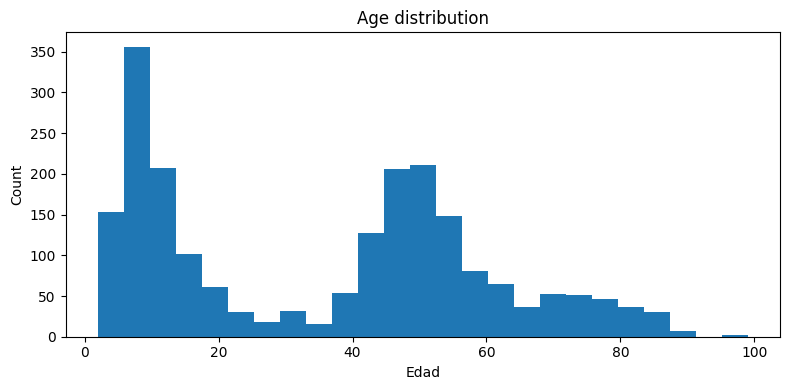

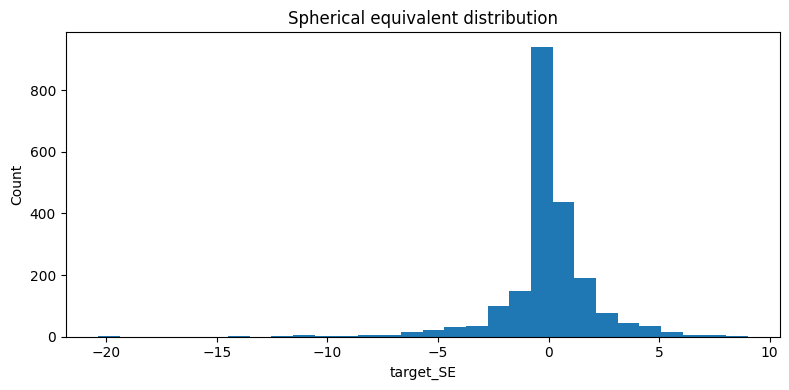

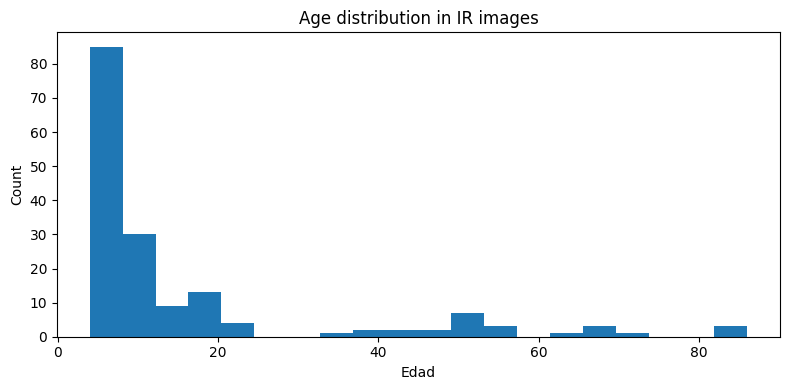

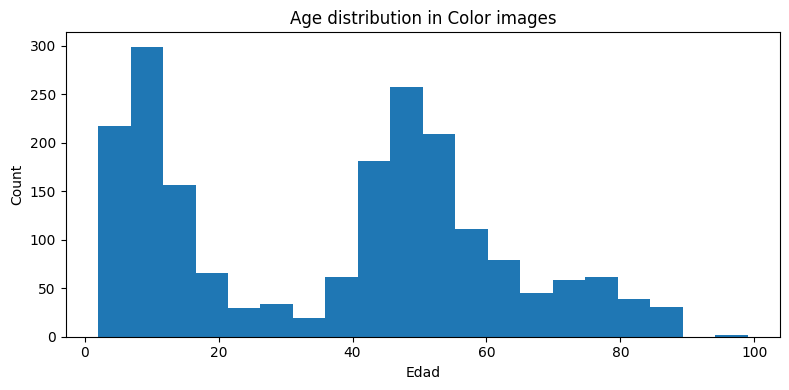

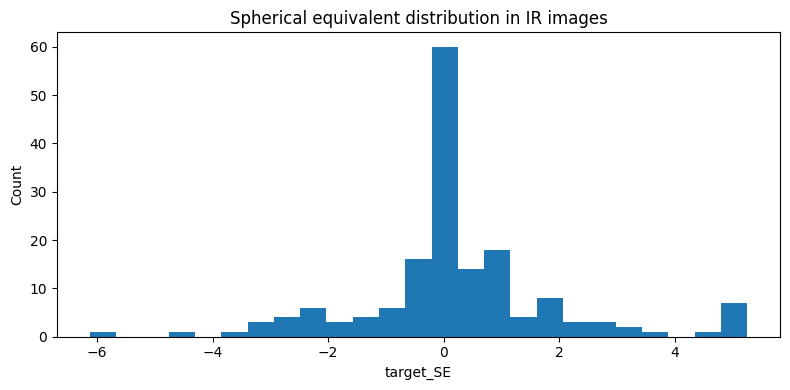

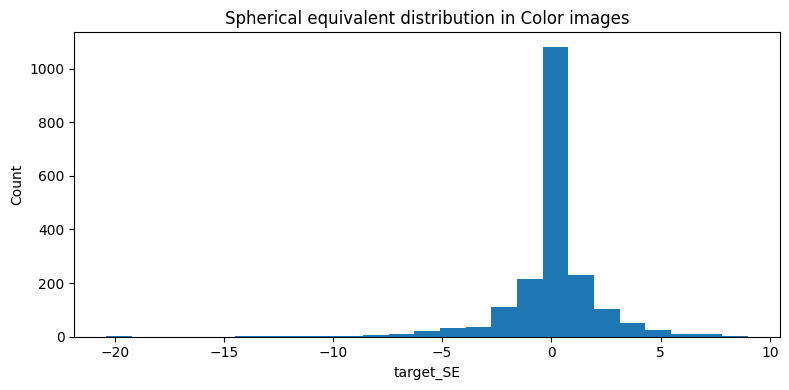

In [34]:
plot_histogram(df, "Edad", bins=25, title="Age distribution")
plot_histogram(df, "target_SE", bins=30, title="Spherical equivalent distribution")

plot_histogram(df_ir, "Edad", bins=20, title="Age distribution in IR images")
plot_histogram(df_color, "Edad", bins=20, title="Age distribution in Color images")

plot_histogram(df_ir, "target_SE", bins=25, title="Spherical equivalent distribution in IR images")
plot_histogram(df_color, "target_SE", bins=25, title="Spherical equivalent distribution in Color images")

### 14) Plots: boxplots

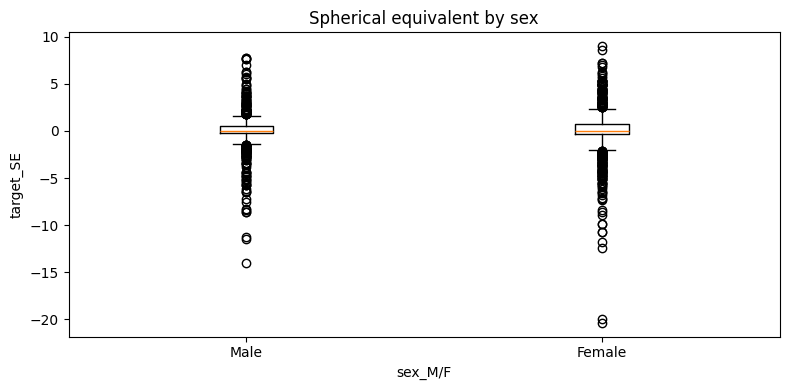

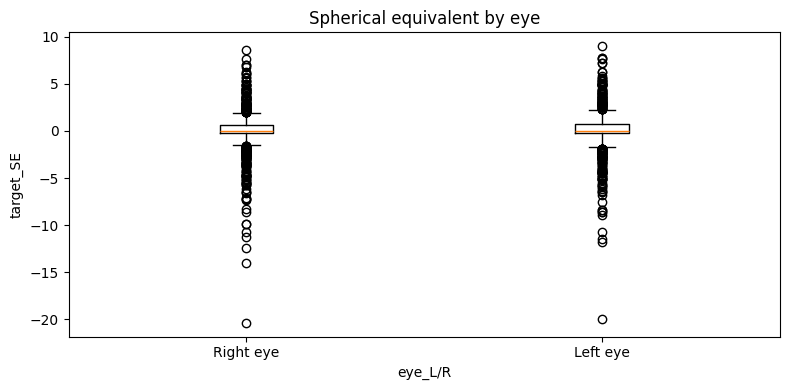

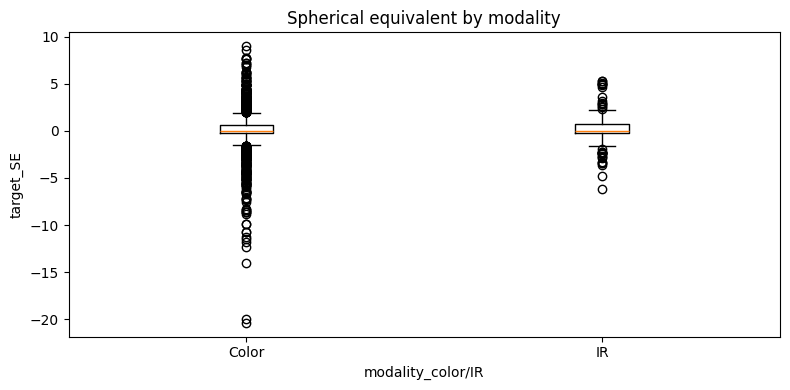

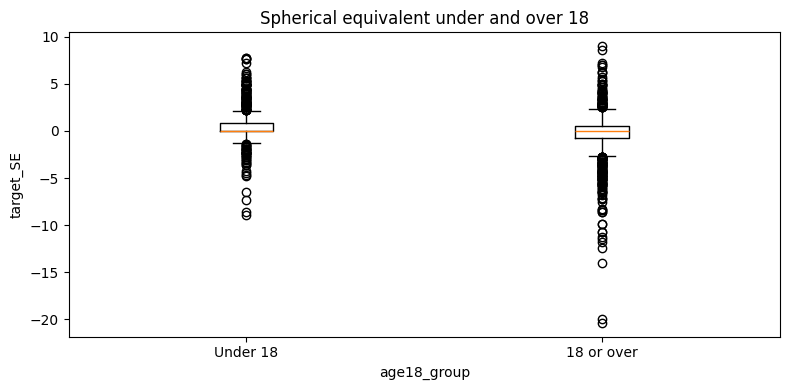

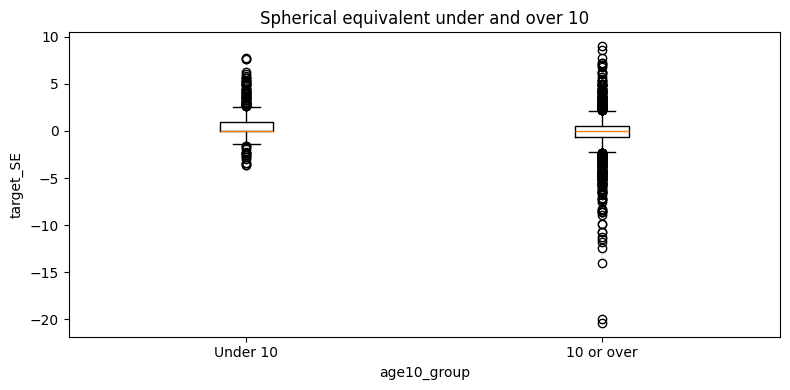

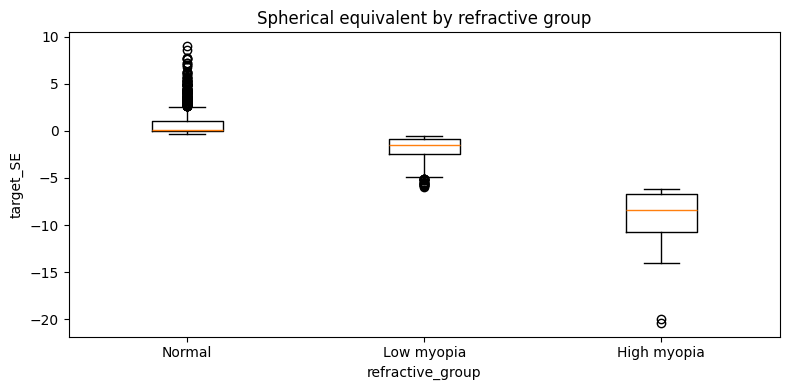

In [35]:
plot_grouped_boxplot(df, "sex_M/F", "target_SE", title="Spherical equivalent by sex")
plot_grouped_boxplot(df, "eye_L/R", "target_SE", title="Spherical equivalent by eye")
plot_grouped_boxplot(df, "modality_color/IR", "target_SE", title="Spherical equivalent by modality")
plot_grouped_boxplot(df, "age18_group", "target_SE", title="Spherical equivalent under and over 18")
plot_grouped_boxplot(df, "age10_group", "target_SE", title="Spherical equivalent under and over 10")
plot_grouped_boxplot(df, "refractive_group", "target_SE", title="Spherical equivalent by refractive group")

### 15) Scatter: age vs diopters

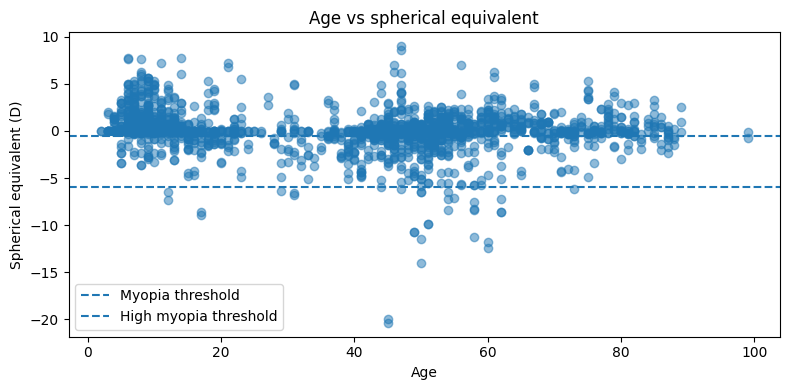

In [32]:
plt.figure(figsize=(8, 4))
plt.scatter(df["Edad"], df["target_SE"], alpha=0.5)
plt.axhline(MYOPIA_THRESHOLD, linestyle="--", label="Myopia threshold")
plt.axhline(HIGH_MYOPIA_THRESHOLD, linestyle="--", label="High myopia threshold")
plt.title("Age vs spherical equivalent")
plt.xlabel("Age")
plt.ylabel("Spherical equivalent (D)")
plt.legend()
plt.tight_layout()

plt.show()

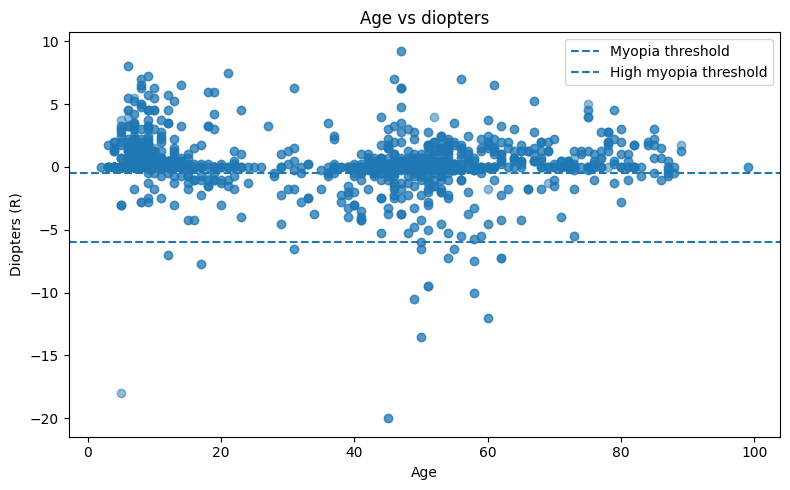

In [19]:
# 15) Scatter: age vs diopters

plt.figure(figsize=(8, 5))
plt.scatter(df["Edad"], df["OD_ESF"], alpha=0.5)
plt.axhline(MYOPIA_THRESHOLD, linestyle="--", label="Myopia threshold")
plt.axhline(HIGH_MYOPIA_THRESHOLD, linestyle="--", label="High myopia threshold")
plt.title("Age vs diopters")
plt.xlabel("Age")
plt.ylabel("Diopters (R)")
plt.legend()
plt.tight_layout()

plt.show()


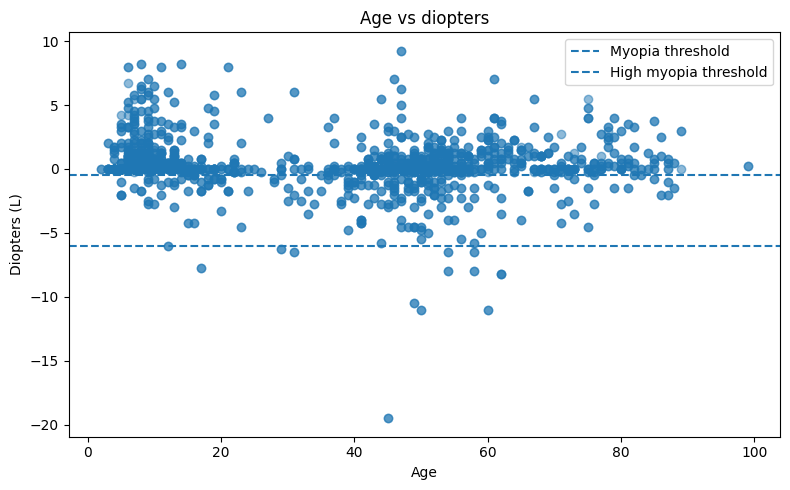

In [20]:
# 15) Scatter: age vs diopters

plt.figure(figsize=(8, 5))
plt.scatter(df["Edad"], df["OI_ESF"], alpha=0.5)
plt.axhline(MYOPIA_THRESHOLD, linestyle="--", label="Myopia threshold")
plt.axhline(HIGH_MYOPIA_THRESHOLD, linestyle="--", label="High myopia threshold")
plt.title("Age vs diopters")
plt.xlabel("Age")
plt.ylabel("Diopters (L)")
plt.legend()
plt.tight_layout()

plt.show()

Diopters and SE seem to be showing a similar distribution (good!)

### 16) Final compact table for TFG

In [21]:
def get_n_images(condition):
    return int(condition.sum())

def get_n_patients(condition):
    return int(df.loc[condition, "patient_id"].nunique())

final_rows = [
    ("Total", len(df), df["patient_id"].nunique()),
    ("Normal", get_n_images(df["myopia/normal"] == "Normal"), get_n_patients(df["myopia/normal"] == "Normal")),
    ("Myopia", get_n_images(df["myopia/normal"] == "Myopia"), get_n_patients(df["myopia/normal"] == "Myopia")),
    ("Low myopia", get_n_images(df["refractive_group"] == "Low myopia"), get_n_patients(df["refractive_group"] == "Low myopia")),
    ("High myopia", get_n_images(df["refractive_group"] == "High myopia"), get_n_patients(df["refractive_group"] == "High myopia")),
    ("Female", get_n_images(df["sex_M/F"] == "Female"), get_n_patients(df["sex_M/F"] == "Female")),
    ("Male", get_n_images(df["sex_M/F"] == "Male"), get_n_patients(df["sex_M/F"] == "Male")),
    ("Under 18", get_n_images(df["age18_group"] == "Under 18"), get_n_patients(df["age18_group"] == "Under 18")),
    ("18 or over", get_n_images(df["age18_group"] == "18 or over"), get_n_patients(df["age18_group"] == "18 or over")),
    ("Under 10", get_n_images(df["age10_group"] == "Under 10"), get_n_patients(df["age10_group"] == "Under 10")),
    ("10 or over", get_n_images(df["age10_group"] == "10 or over"), get_n_patients(df["age10_group"] == "10 or over")),
    ("Right eye", get_n_images(df["eye_L/R"] == "Right eye"), get_n_patients(df["eye_L/R"] == "Right eye")),
    ("Left eye", get_n_images(df["eye_L/R"] == "Left eye"), get_n_patients(df["eye_L/R"] == "Left eye")),
    ("Color", get_n_images(df["modality_color/IR"].str.upper() == "COLOR"), get_n_patients(df["modality_color/IR"].str.upper() == "COLOR")),
    ("IR", get_n_images(df["modality_color/IR"].str.upper() == "IR"), get_n_patients(df["modality_color/IR"].str.upper() == "IR")),
]

final_table = pd.DataFrame(final_rows, columns=["Group", "N images", "N patients"])
final_table["Image %"] = 100 * final_table["N images"] / len(df)

#Let us have decimals only when NOT an integer
final_table = pd.DataFrame(final_rows, columns=["Group", "N images", "N patients"])
final_table["Image %"] = 100 * final_table["N images"] / len(df)

for col in ["N images", "N patients", "Image %"]:
    final_table[col] = final_table[col].map(
        lambda x: f"{x:.0f}" if float(x).is_integer() else f"{x:.2f}"
    )
display(final_table)

,Group,N images,N patients,Image %
0,Total,2126,1061,100
1,Normal,1645,861,77.38
2,Myopia,481,273,22.62
3,Low myopia,449,262,21.12
4,High myopia,32,19,1.51
5,Female,1315,656,61.85
6,Male,811,405,38.15
7,Under 18,817,407,38.43
8,18 or over,1309,654,61.57
9,Under 10,509,254,23.94


## CONCLUSIONS:

📊 Dataset general
- El dataset final contiene 2126 imágenes correspondientes a 1061 pacientes, con una media de aproximadamente 2 imágenes por paciente.
- La edad de los pacientes abarca un rango muy amplio (2 a 99 años), con una edad media de 35.4 años y una mediana de 42 años.
- El equivalente esférico (SE) presenta un rango muy amplio (−20.38 D a +9 D), lo que indica la presencia tanto de casos extremos de miopía como de hipermetropía.
- El valor medio del SE es prácticamente nulo (0.02 D) y la mediana es 0 D, indicando una distribución global centrada alrededor de la emetropía.
- Existen 126 valores distintos de SE para las 2126 imágenes analizadas, reflejando la naturaleza discretizada de las medidas refractivas clínicas.


👓 Distribución refractiva
- El dataset está claramente desbalanceado hacia sujetos no miopes:
    - Normal: 1645 imágenes (77.4%)
    - Miopía: 481 imágenes (22.6%).
- La miopía alta es extremadamente minoritaria:
    - Normal: 1645 imágenes
    - Miopía baja: 449 imágenes
    - Miopía alta: únicamente 32 imágenes.
- La distribución de SE presenta una fuerte concentración alrededor de 0 D, con colas relativamente largas hacia valores negativos y positivos.
- La presencia de pocos casos extremos y muchos valores cercanos a cero puede dificultar el aprendizaje de modelos de regresión y favorecer predicciones cercanas a la media.


👩‍⚕️ Distribución demográfica
- Existe un predominio femenino:
    - Mujeres: 1315 imágenes
    - Hombres: 811 imágenes.
- La distribución entre ojo derecho e izquierdo es prácticamente perfecta:
    - Ojo izquierdo: 1070 imágenes
    - Ojo derecho: 1056 imágenes.
- La modalidad Color domina ampliamente el dataset:
    - Color: 1960 imágenes (92.2%)
    - IR: 166 imágenes (7.8%).


🎂 Distribución por edades
- El grupo de edad más representado es 45–59 años (620 imágenes).
- Los menores de 10 años representan aproximadamente 509 imágenes.
- Los menores de 18 años representan aproximadamente 817 imágenes.
- La distribución de edades es claramente multimodal, sugiriendo la coexistencia de poblaciones pediátricas y adultas dentro del mismo dataset.


📈 Relación entre edad y miopía
- La prevalencia de miopía es mucho menor en menores de 10 años (4.3%) que en adultos jóvenes.
- El grupo de 30–44 años presenta la mayor proporción de miopía (~43%).
- La prevalencia de miopía disminuye nuevamente en los grupos de mayor edad (>60 años).
- La relación entre edad y SE no parece lineal, observándose distintos patrones según los grupos etarios.


🌈 Modalidad IR
- Las imágenes IR constituyen una minoría muy reducida del dataset (166 imágenes).
- Los pacientes con imágenes IR son considerablemente más jóvenes que la población global.
- Aproximadamente:
    - 58% de las imágenes IR pertenecen a menores de 10 años.
    - 20% pertenecen al grupo 10–17 años.
- La modalidad de adquisición parece estar asociada con la edad del paciente, por lo que podría introducir un sesgo demográfico en modelos entrenados conjuntamente con imágenes Color.


🤖 Implicaciones para los modelos de IA
- Clasificación
    - Existe un desbalance moderado entre clases (77% normal vs 23% miopía).
    - La miopía alta está severamente infrarrepresentada.
    - Será importante monitorizar métricas más allá de accuracy (AUC, sensibilidad, especificidad, F1).
- Regresión
    - El target está fuertemente concentrado alrededor de 0 D.
    - Los casos extremos son escasos.
    - El rango total de SE es muy amplio (−20 D a +9 D).
    - El modelo podría tender a minimizar el error prediciendo valores cercanos a la media.
    - El R² puede verse penalizado por la combinación de:
        - alta concentración alrededor de 0,
        - presencia de outliers extremos,
        - escasez de muestras en los extremos refractivos.
- Generalización
- El dataset es mucho más heterogéneo que el utilizado en tu TFG anterior:
    - amplio rango de edades,
    - múltiples modalidades,
    - pacientes reales de entorno clínico,
    - distribución refractiva natural.
- Por tanto, las métricas obtenidas probablemente representarán mejor el rendimiento esperado en escenarios clínicos reales.

De todas estas, para investigar los R² bajos, las tres que más me hacen levantar la ceja son:

77% de los datos están cerca de emetropía.
Solo 32 imágenes de miopía alta.
Rango enorme (-20 a +9 D) con muy pocos ejemplos en los extremos.

Eso por sí solo ya puede hacer que un modelo tenga MAE razonable pero R² decepcionante.